# ¿Que es una serie de tiempo?

Una serie de tiempo es una secuencia de datos medidos en puntos sucesivos en el tiempo, generalmente a intervalos uniformes.

$$Y_t = \{y_1, y_2, \dots, y_T\}$$

## ¿Que tipos de datos tenemos en series de tiempo?

Por frecuencia: 

- Datos de alta frecuencia: datos recogidos en intervalos muy cortos (segundos, minutos).

- Datos de baja frecuencia: datos recogidos en intervalos más largos (días, meses, años).

Por estadistica:

- Datos estacionarios: propiedades estadísticas constantes en el tiempo (media, varianza).

- Datos no estacionarios: propiedades estadísticas que cambian con el tiempo (tendencias, estacionalidad).


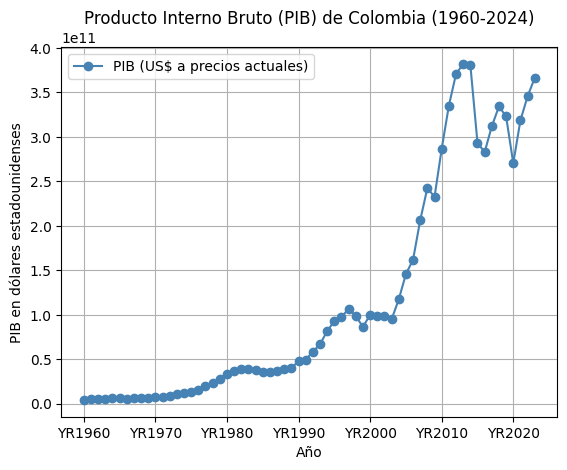

In [27]:
import pandas as pd
import matplotlib.pyplot as plt
import wbgapi as wb

data = wb.data.DataFrame(series="NY.GDP.MKTP.CD",economy="COL",time=range(1960,2024),columns="series").reset_index()
data.columns = ['Año', 'PIB (US$ a precios actuales)']

data.plot(x='Año', y='PIB (US$ a precios actuales)', kind='line', marker='o', color='steelblue')
plt.title('Producto Interno Bruto (PIB) de Colombia (1960-2024)')
plt.xlabel('Año')
plt.ylabel('PIB en dólares estadounidenses')
plt.grid()
plt.show()

## Caracteristicas de las Series de Tiempo

- Tendencia: dirección general a largo plazo de la serie. Puede ser creciente, decreciente o constante.

- Estacionalidad: patrones que se repiten en intervalos regulares (diarios, mensuales, anuales). Está asociada a factores climáticos, sociales o económicos esperados.

- Ciclos: fluctuaciones a largo plazo que no son de naturaleza estacional. Usualmente asociadas a ciclos económicos.

- Ruido: variabilidad aleatoria e impredecible en los datos.

### Estacionalidad en las Series de Tiempo

Es un patrón que se repite en intervalos regulares dentro de una serie de tiempo.

- Ventas minoristas que aumentan durante la temporada navideña.
- Aumento de la demanda de energía durante los meses de verano o invierno.
- Fluctuaciones en la agricultura debido a las estaciones del año.

La estacionalidad puede ser diaria, semanal, mensual o anual, dependiendo del contexto de la serie de tiempo.

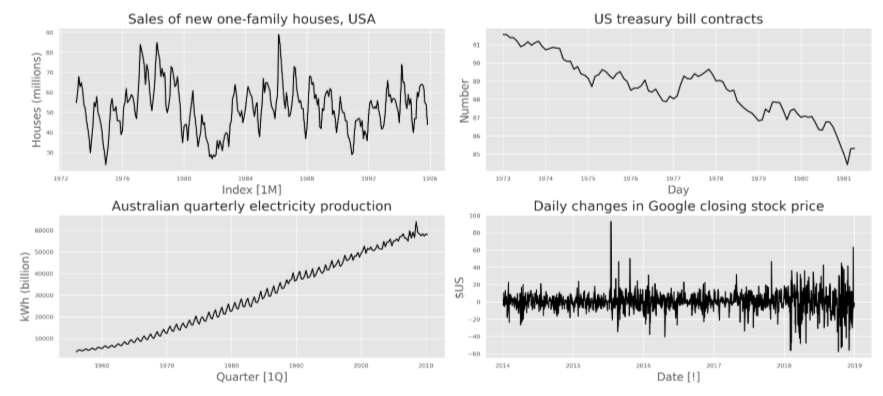

### Tendencia en las Series de Tiempo

Cuando hablamos de ver o acertar la tendencia de una serie, siempre nos refiriremos al metodo de la **MEDIA MOVIL**

####  Media Movil (estimacion de tendencia)

Es una técnica sencilla para suavizar una serie de tiempo y estimar su componente de tendencia. La media móvil ayuda a reducir la variabilidad de corto plazo y resaltar la tendencia subyacente en los datos

Fórmula de la media móvil simple (SMA) de orden k:

$$SMA_t = \frac{1}{k} \sum_{i=0}^{k-1} Y_{t-i}$$




In [28]:
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf

ticker = "EC"

# Descargemos los datos
df_ecopetrol = yf.download(ticker, start="2020-01-01",end="2026-02-20")
df_ecopetrol.head(5)

[*********************100%***********************]  1 of 1 completed

Price,Close,High,Low,Open,Volume
Ticker,EC,EC,EC,EC,EC
Date,,,,,
2020-01-02,10.163625,10.213667,10.083557,10.083557,264900
2020-01-03,10.248695,10.358789,10.188645,10.303742,682700
2020-01-06,10.208661,10.273717,10.148611,10.258704,397200
2020-01-07,10.258704,10.298738,10.143607,10.168628,559200
2020-01-08,10.178637,10.278722,10.108577,10.138603,1498200


In [29]:
df_ecopetrol.columns = df_ecopetrol.columns.get_level_values(0)
df_ecopetrol = df_ecopetrol.reset_index()
df_ecopetrol = df_ecopetrol[["Date","Close"]]
df_ecopetrol.head(5)

Price,Date,Close
0,2020-01-02,10.163625
1,2020-01-03,10.248695
2,2020-01-06,10.208661
3,2020-01-07,10.258704
4,2020-01-08,10.178637


<Figure size 1000x1000 with 0 Axes>

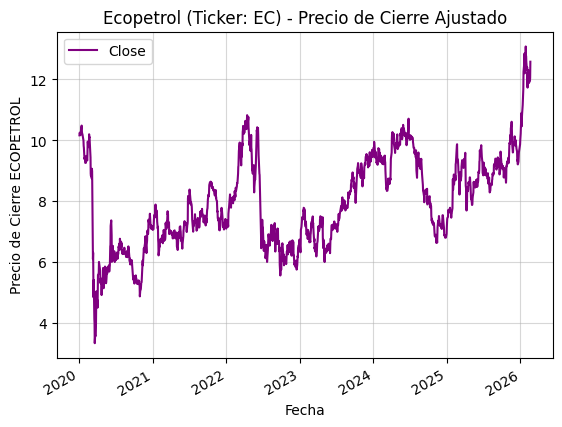

In [30]:
plt.figure(figsize=(10,10))
df_ecopetrol.plot(x="Date",y="Close",color="purple")
plt.title('Ecopetrol (Ticker: EC) - Precio de Cierre Ajustado')
plt.ylabel("Precio de Cierre ECOPETROL")
plt.xlabel("Fecha")
plt.grid(True,alpha=0.5)
plt.show()

Esa es la serie de tiempo del Precio de Cierre ajustado en ECOPETROL, ahora vemos cual es la Tendencia de esta serie de tiempo con las medias moviles

In [31]:
df_ecopetrol["Media_movil_k10"] = df_ecopetrol["Close"].rolling(10).mean()
df_ecopetrol["Media_movil_k30"] = df_ecopetrol["Close"].rolling(window=10).mean()

df_ecopetrol.head(5)

Price,Date,Close,Media_movil_k10,Media_movil_k30
0,2020-01-02,10.163625,NaN,NaN
1,2020-01-03,10.248695,NaN,NaN
2,2020-01-06,10.208661,NaN,NaN
3,2020-01-07,10.258704,NaN,NaN
4,2020-01-08,10.178637,NaN,NaN


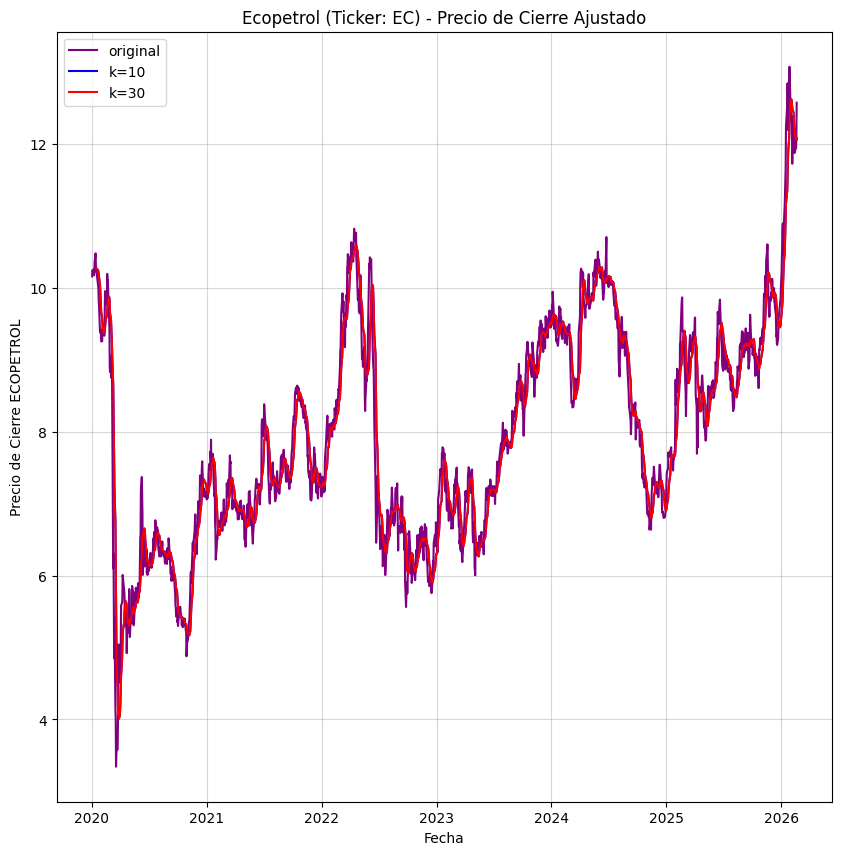

In [34]:
plt.figure(figsize=(10,10))
plt.plot(df_ecopetrol["Date"],df_ecopetrol["Close"],color="purple",label="original")
plt.plot(df_ecopetrol["Date"],df_ecopetrol["Media_movil_k10"],color="blue",label="k=10")
plt.plot(df_ecopetrol["Date"],df_ecopetrol["Media_movil_k30"],color="red",label="k=30")
plt.title('Ecopetrol (Ticker: EC) - Precio de Cierre Ajustado')
plt.ylabel("Precio de Cierre ECOPETROL")
plt.xlabel("Fecha")
plt.grid(True,alpha=0.5)
plt.legend()
plt.show()

Lo que hace la media movil es perseguir pero con menor amplitud la serie de tiempo

## Descompocision de una Serie de tiempo

¿Para que queremos descomponer una Serie de tiempo?

Buscamos descomponer una serie de tiempo (como los datos de Ecopetrol) principalmente para aislar los patrones subyacentes que están mezclados en los datos brutos. Una serie observada ($Y_t$) suele ser la suma (o producto) de tres componentes clave más el error.

Al descomponer, puedes ver claramente qué parte del movimiento del precio de Ecopetrol se debe a:

- Tendencia ($T_t$): La dirección a largo plazo (¿va hacia arriba o hacia abajo en los últimos 5 años?).

- Estacionalidad ($S_t$): Patrones que se repiten en periodos fijos (como vimos: ¿sube la acción siempre en cierta época del año?).

- Residuo ($I_t$ o $E_t$): Lo aleatorio, el "ruido" o eventos inesperados que no siguen un patrón.

Para los modelos de regresión avanzados (como los que veremos), se requiere que la serie sea estacionaria (que su media y varianza no cambien en el tiempo)

- Nota técnica: Al eliminar la tendencia y la estacionalidad, te quedas con los "residuos". Si estos residuos se comportan como ruido blanco, significa que has extraído toda la información útil de la serie.

Existen varios metodos para descomponer series, sin embargo, nosotros usaremos uno principal el cual es el **STL**

### **STL** (Seasonal-Trend decomposition using Loess)

En comparación con otros métodos, el STL ofrece tres ventajas críticas para analizar activos como Ecopetrol:

- Maneja cualquier tipo de estacionalidad
- Robustez ante valores atípicos (Outliers)



In [35]:
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import STL

df_ecopetrol.index = pd.to_datetime(df_ecopetrol["Date"])

In [36]:
df_ecopetrol.head(3)

Price,Date,Close,Media_movil_k10,Media_movil_k30
Date,,,,
2020-01-02,2020-01-02,10.163625,NaN,NaN
2020-01-03,2020-01-03,10.248695,NaN,NaN
2020-01-06,2020-01-06,10.208661,NaN,NaN


In [45]:
stl = STL(df_ecopetrol['Close'], period=252) 
result = stl.fit()

componentes = {
    "Original": df_ecopetrol['Close'],
    "Tendencia": result.trend,
    "Estacionalidad": result.seasonal,
    "Residuos": result.resid
}

colors = ["blue","orange","green","red"]

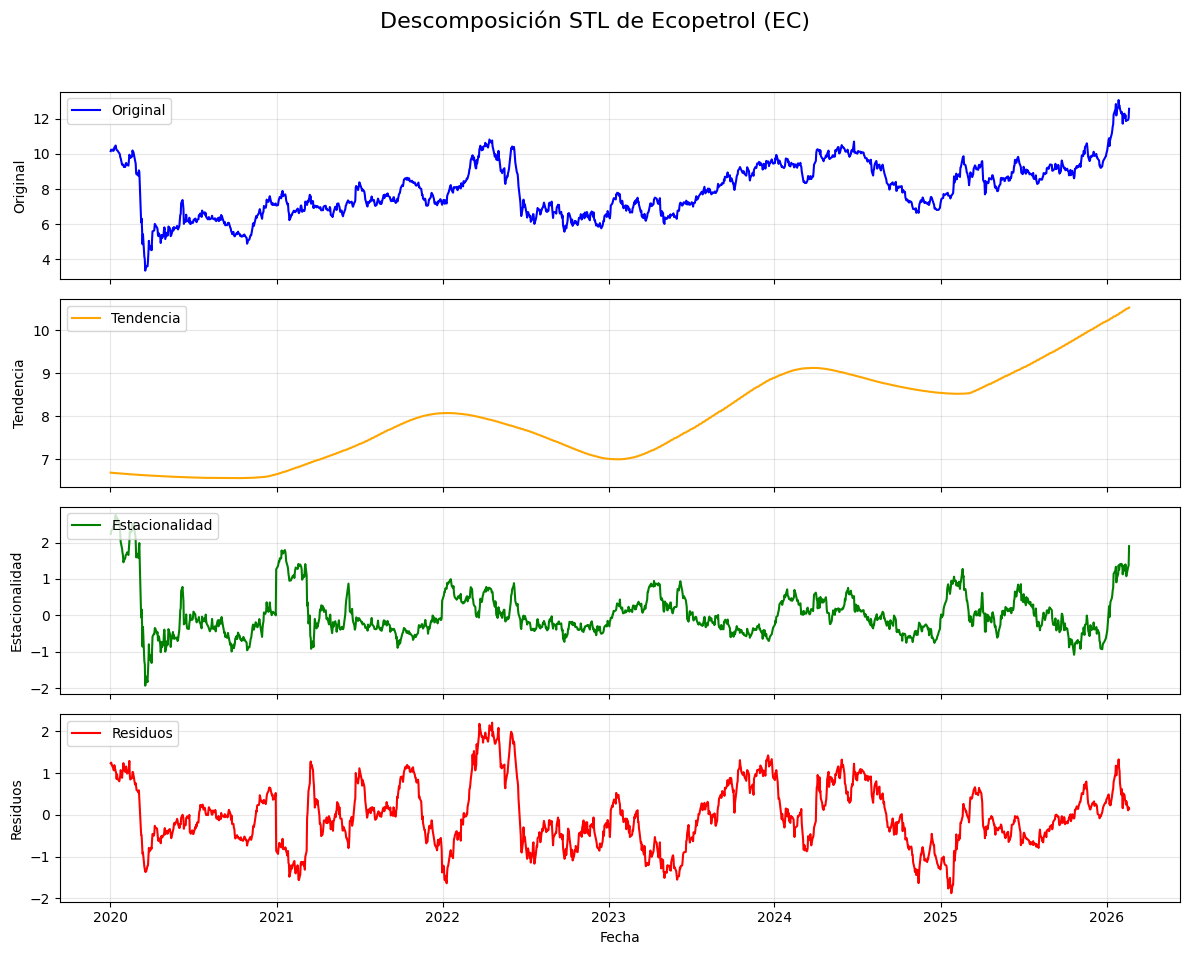

In [48]:
fig, axes = plt.subplots(4, 1, figsize=(12, 10), sharex=True)

for i, (key, value) in enumerate(componentes.items()):
    axes[i].plot(value, label=key, color=colors[i], linewidth=1.5)
    axes[i].legend(loc="upper left")
    axes[i].grid(True, alpha=0.3)
    # Añadimos el nombre del componente como título interno o y-label
    axes[i].set_ylabel(key)

plt.xlabel("Fecha")
plt.suptitle("Descomposición STL de Ecopetrol (EC)", fontsize=16)
plt.tight_layout(rect=[0, 0.03, 1, 0.95]) # Ajuste para que el título no se solape
plt.show()